In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.dates as mdates

In [2]:
df = pd.read_parquet('data/v80_new_features/final_model_data_the_rescaled.parquet')
df[['Event_class', '|V_perp|']] = pd.read_parquet('data/v80/final_matrix_the_perp_labeled_v80.parquet')[['Event_class', '|V_perp|']][2:].reset_index(drop=True)
df_importance = pd.read_parquet("data/v80_new_features/the_timestep_importance_mad_standardized.parquet")

In [3]:
df['Time'] = pd.to_datetime(df['Epoch_time'], unit='s', utc=True)

In [4]:
df_importance["year"] = pd.to_datetime(df_importance["Time"]).dt.year

In [5]:
features = [
    'Bx', 'By', 'Bz', 'Bx_lag_1', 'Bx_lag_2', 'By_lag_1',
    'By_lag_2', 'Bz_lag_1', 'Bz_lag_2', 'Bx_conditional_vol',
    'By_conditional_vol', 'Bz_conditional_vol', 'LIM_scale_2_log',
    'LIM_scale_4_log', 'LIM_scale_8_log', 'LIM_scale_16_log',
    'LIM_scale_32_log', 'LIM_scale_64_log'
]

feat_cols = [
    'Bx_conditional_vol', 'By_conditional_vol', 'Bz_conditional_vol', 
    'LIM_scale_2_log', 'LIM_scale_4_log', 'LIM_scale_8_log',
    'LIM_scale_16_log', 'LIM_scale_32_log', 'LIM_scale_64_log'
]

feat_labels = [
    r"$B_x$ Volatility",
    r"$B_y$ Volatility",
    r"$B_z$ Volatility",
    "LIM Scale 2",
    "LIM Scale 4",
    "LIM Scale 8",
    "LIM Scale 16",
    "LIM Scale 32",
    "LIM Scale 64",
]

target = ['Event_label_80']

In [6]:
# 1. Color mapping keyed to original column names
color_dict = {
    # GARCH Volatilities
    "Bx_conditional_vol": "blue",
    "By_conditional_vol": "limegreen",
    "Bz_conditional_vol": "red",
    # LIM Scales (Dyadic Teal Gradient)
    "LIM_scale_2_log": "#80cbc4",
    "LIM_scale_4_log": "#4db6ac",
    "LIM_scale_8_log": "#00796b",
    "LIM_scale_16_log": "#00695c",
    "LIM_scale_32_log": "#005a4f",
    "LIM_scale_64_log": "#004d40",
}

# 2. Publication label mapping (removes '_log', standardizes names)
clean_label_dict = {
    "LIM_scale_2_log": "LIM Scale 2",
    "LIM_scale_4_log": "LIM Scale 4",
    "LIM_scale_8_log": "LIM Scale 8",
    "LIM_scale_16_log": "LIM Scale 16",
    "LIM_scale_32_log": "LIM Scale 32",
    "LIM_scale_64_log": "LIM Scale 64",
    "Bx_conditional_vol": r"$B_x$ Volatility",
    "By_conditional_vol": r"$B_y$ Volatility",
    "Bz_conditional_vol": r"$B_z$ Volatility",
    "Bx": r"$B_x$",
    "By": r"$B_y$",
    "Bz": r"$B_z$",
    "Bx_lag_1": r"$B_x$ Lag 1",
    "Bx_lag_2": r"$B_x$ Lag 2",
    "By_lag_1": r"$B_y$ Lag 1",
    "By_lag_2": r"$B_y$ Lag 2",
    "Bz_lag_1": r"$B_z$ Lag 1",
    "Bz_lag_2": r"$B_z$ Lag 2",
}

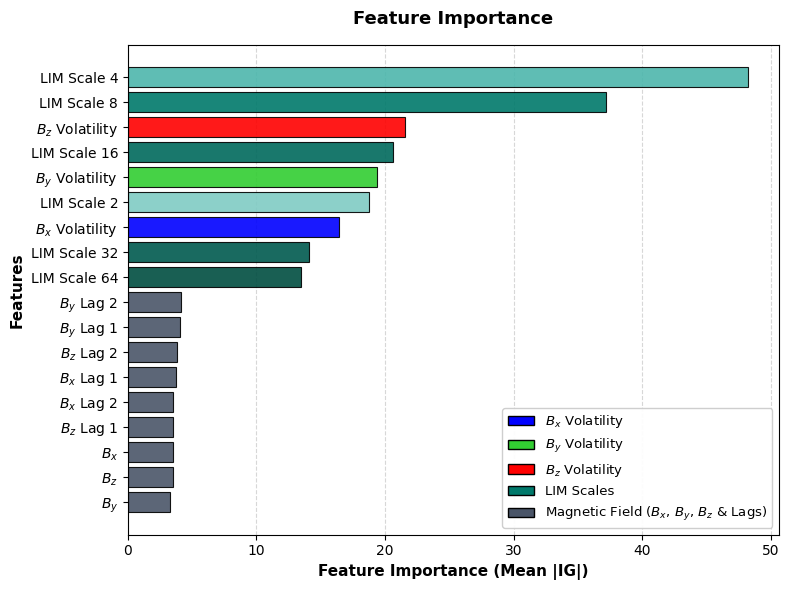

In [7]:
# 3. Compute mean attribution strictly during fast flow events (Event_label_80 == 1)
event_mask = df_importance["Event_label_80"] == 1
summary_series = (
    df_importance.loc[event_mask, features]
    .mean()
    .sort_values(ascending=True)
)

# 4. Apply matching colors and clean labels
panel_colors = [color_dict.get(f, "#4a5568") for f in summary_series.index]
clean_labels = [clean_label_dict.get(f, f) for f in summary_series.index]

# 5. Plot
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

bars = ax.barh(
    clean_labels,
    summary_series.values,
    color=panel_colors,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.8,
)

ax.set_xlabel(
    r"Feature Importance (Mean |IG|)",
    fontsize=11,
    fontweight="bold",
)
ax.set_ylabel("Features", fontsize=11, fontweight="bold")
ax.set_title(
    "Feature Importance",
    pad=15,
    fontsize=13,
    fontweight="bold",
)
ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="--", alpha=0.5)

legend_elements = [
    Patch(facecolor="blue", edgecolor="black", label=r"$B_x$ Volatility"),
    Patch(facecolor="limegreen", edgecolor="black", label=r"$B_y$ Volatility"),
    Patch(facecolor="red", edgecolor="black", label=r"$B_z$ Volatility"),
    Patch(facecolor="#00796b", edgecolor="black", label="LIM Scales"),
    Patch(
        facecolor="#4a5568",
        edgecolor="black",
        label=r"Magnetic Field ($B_x$, $B_y$, $B_z$ & Lags)",
    ),
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    framealpha=0.95,
    fontsize=9.5,
)

plt.tight_layout()
plt.show()

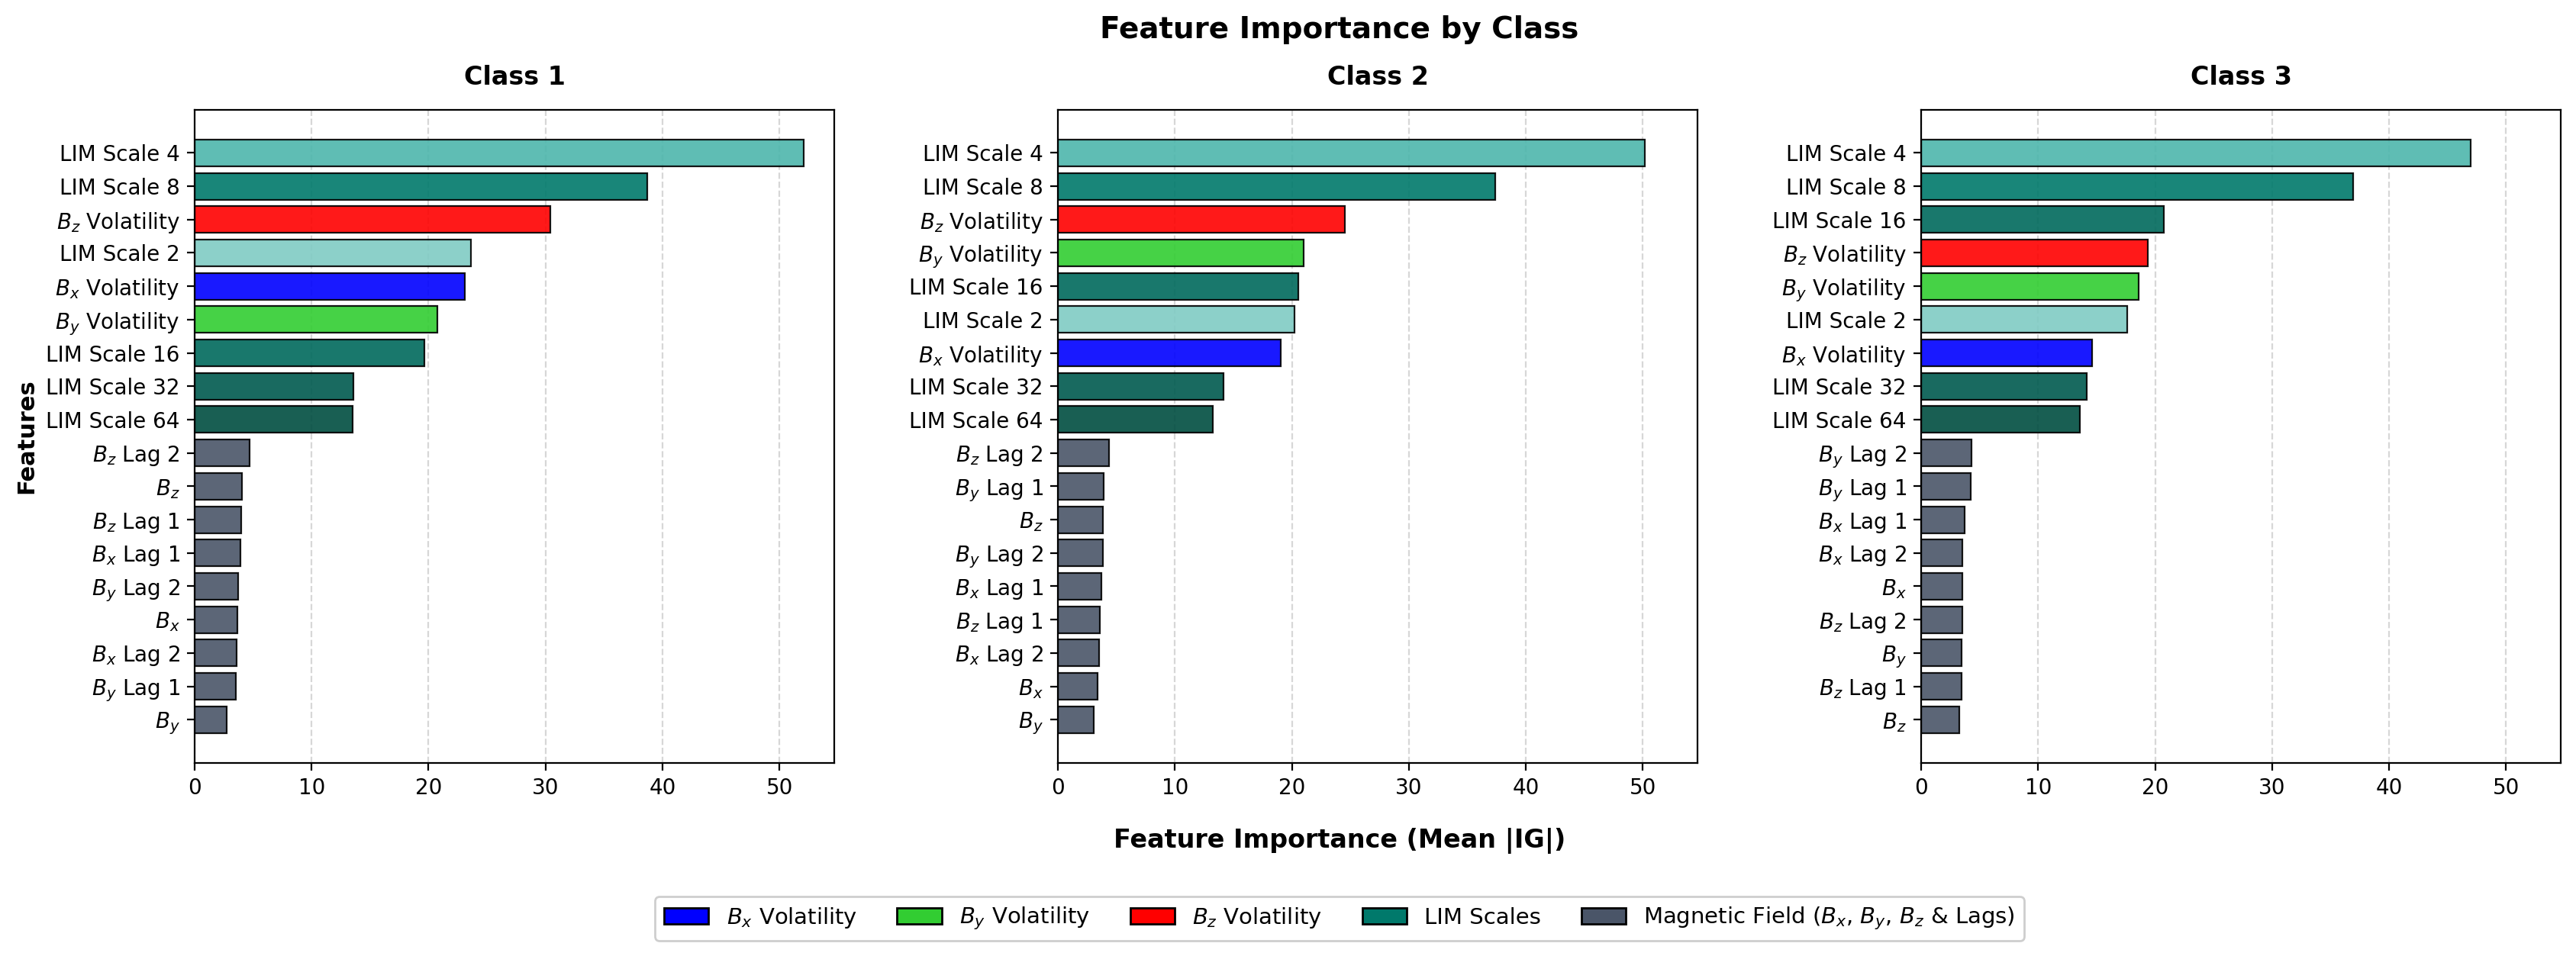

In [8]:
class_titles = {
    1: r"Class 1",
    2: r"Class 2",
    3: r"Class 3",
}

# Filter strictly for fast flow events directly from df_importance
event_mask = df_importance["Event_label_80"] == 1
df_events = df_importance[event_mask]

# sharey=False so each panel displays its own ranked features
fig, axes = plt.subplots(
    1, 3, figsize=(20, 6.2), dpi=200, sharey=False, sharex=True
)

for ax, cls in zip(axes, [1, 2, 3]):
    # Sort ascending individually per class using the original column names
    cls_series = (
        df_events[df_events["Event_class"] == cls][features]
        .mean()
        .sort_values(ascending=True)
    )

    # Color assignment based on original feature keys
    panel_colors = [color_dict.get(f, "#4a5568") for f in cls_series.index]

    # Map the y-axis tick indices to clean display names
    clean_labels = [clean_label_dict.get(f, f) for f in cls_series.index]

    ax.barh(
        clean_labels,
        cls_series.values,
        color=panel_colors,
        alpha=0.9,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.set_title(class_titles[cls], fontsize=12, fontweight="bold", pad=12)
    ax.set_axisbelow(True)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

axes[0].set_ylabel("Features", fontsize=11, fontweight="bold")
fig.text(
    0.5,
    0.10,
    r"Feature Importance (Mean |IG|)",
    ha="center",
    fontsize=12,
    fontweight="bold",
)

legend_elements = [
    Patch(facecolor="blue", edgecolor="black", label=r"$B_x$ Volatility"),
    Patch(facecolor="limegreen", edgecolor="black", label=r"$B_y$ Volatility"),
    Patch(facecolor="red", edgecolor="black", label=r"$B_z$ Volatility"),
    Patch(facecolor="#00796b", edgecolor="black", label="LIM Scales"),
    Patch(
        facecolor="#4a5568",
        edgecolor="black",
        label=r"Magnetic Field ($B_x$, $B_y$, $B_z$ & Lags)",
    ),
]

# Horizontal bottom legend centered across the canvas
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=5,
    frameon=True,
    framealpha=0.95,
    fontsize=10.5,
    columnspacing=1.8,
)

plt.suptitle(
    "Feature Importance by Class",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)

plt.subplots_adjust(bottom=0.19, top=0.88, wspace=0.35)
plt.show()

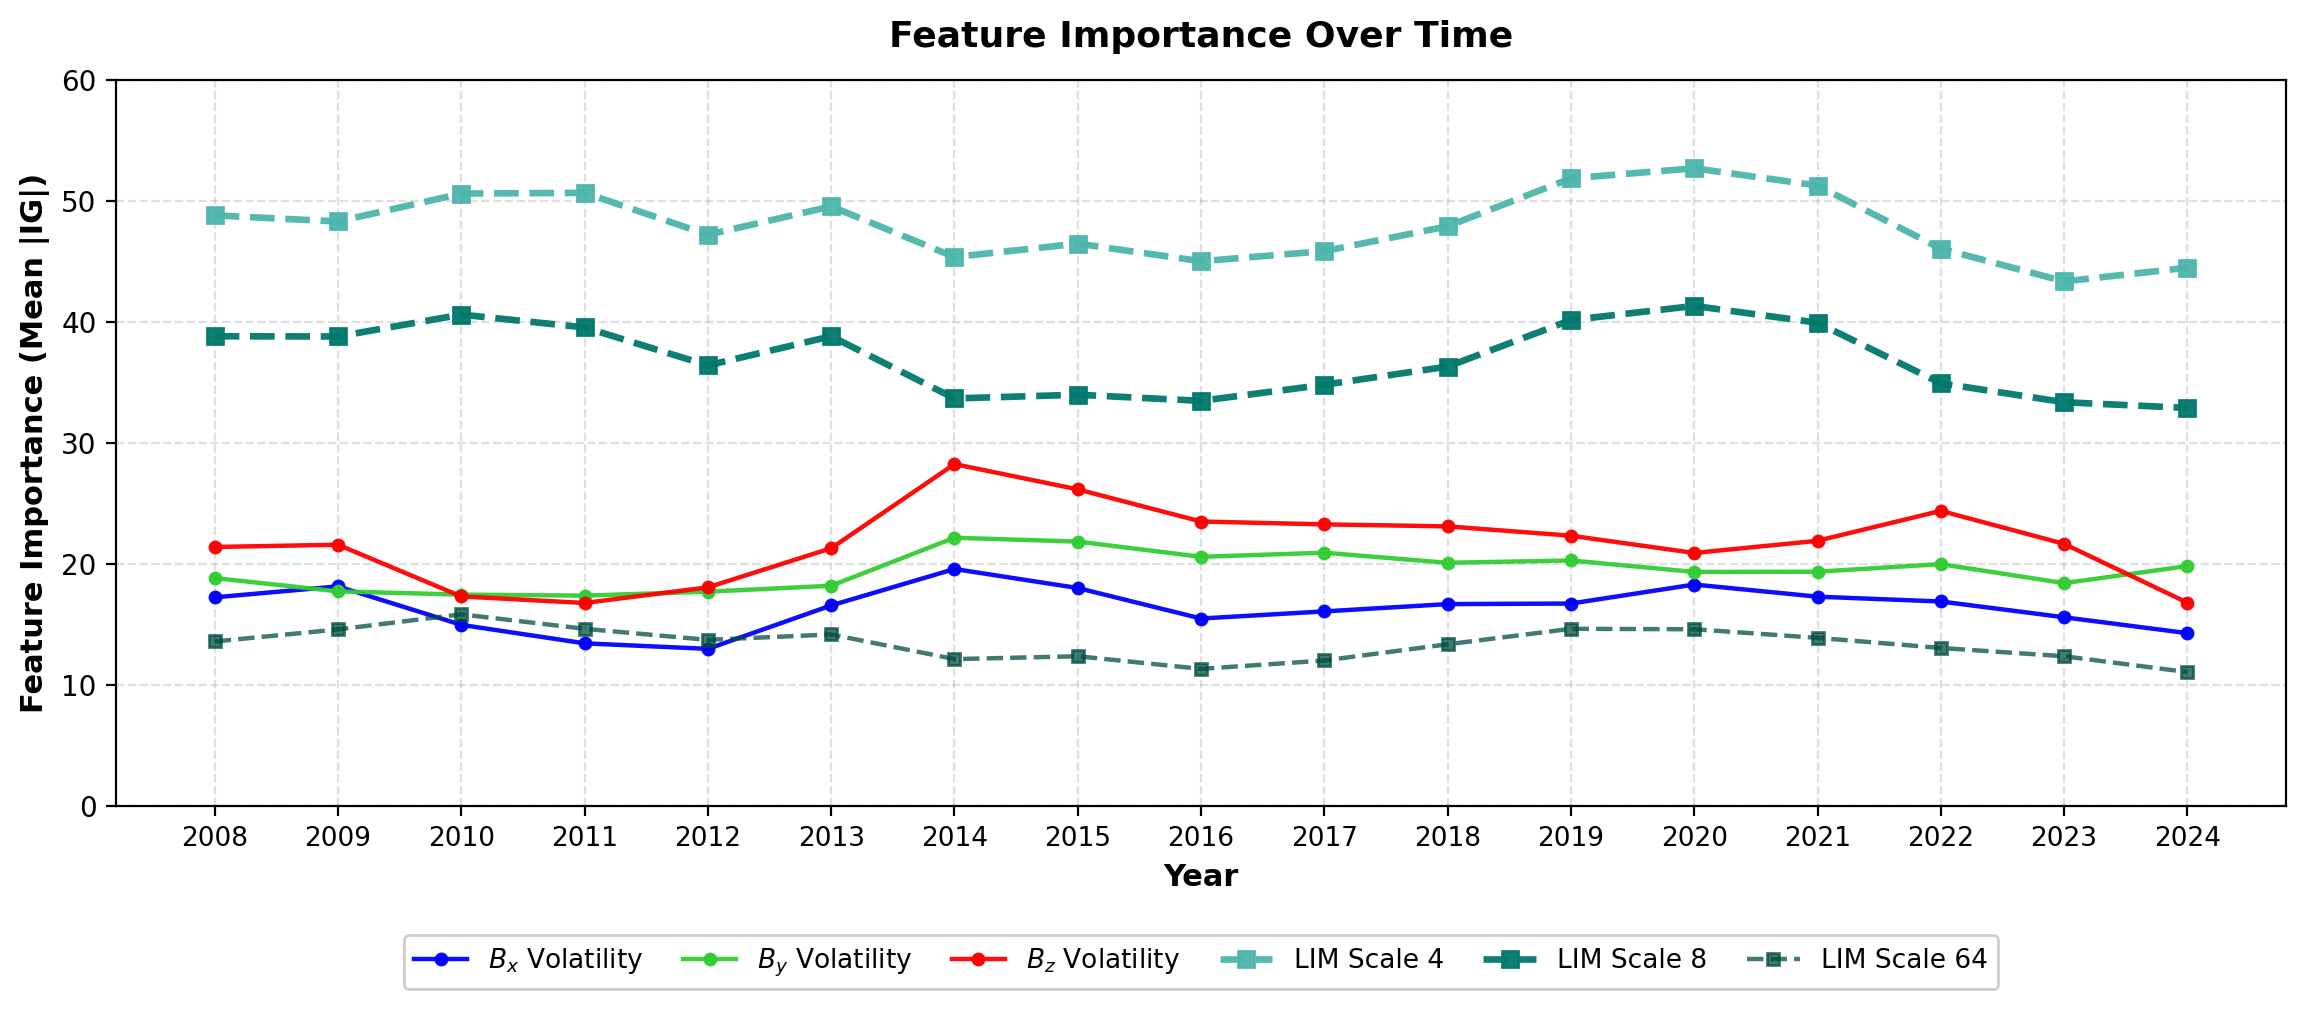

In [9]:
# 3. Features to display over time (Dynamic Volatilities + Dyadic LIM scales)
time_features = [
    'Bx_conditional_vol', 'By_conditional_vol', 'Bz_conditional_vol', 
    'LIM_scale_4_log', 'LIM_scale_8_log', 'LIM_scale_64_log'
]
# 4. Filter strictly for fast flow events within 2008–2024
all_years = np.arange(2008, 2025)

event_mask = (
    (df_importance["Event_label_80"] == 1)
    & (df_importance["year"] >= 2008)
    & (df_importance["year"] <= 2024)
)

yearly_means = (
    df_importance.loc[event_mask]
    .groupby("year")[time_features]
    .mean()
    .reindex(all_years)
)

# 5. Plot Line Trajectories
fig, ax = plt.subplots(figsize=(14, 5.5), dpi=200)

for feat in time_features:
    is_lim = "LIM" in feat
    is_top = feat in ["LIM_scale_4_log", "LIM_scale_8_log"]

    ax.plot(
        yearly_means.index,
        yearly_means[feat],
        color=color_dict[feat],
        marker="o" if not is_lim else "s",
        markersize=5.5 if is_top else 4.0,
        linewidth=2.4 if is_top else 1.6,
        linestyle="--" if is_lim else "-",
        alpha=0.95 if is_top or "conditional_vol" in feat else 0.75,
        label=clean_label_dict[feat],
    )

ax.set_title("Feature Importance Over Time", fontsize=13, fontweight="bold", pad=12)

ax.set_xlabel("Year", fontsize=11, fontweight="bold")
ax.set_ylabel(
    "Feature Importance (Mean |IG|)",
    fontsize=11,
    fontweight="bold",
)

ax.set_xticks(all_years)
ax.set_xticklabels(all_years, rotation=0, fontsize=9.5)
ax.set_ylim(0, 60)
ax.grid(True, linestyle="--", alpha=0.4)

# Legend horizontally centered across bottom
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=6,
    frameon=True,
    framealpha=0.95,
    fontsize=9.5,
    columnspacing=1.5,
)

plt.subplots_adjust(bottom=0.22)
plt.show()

In [10]:
df_importance['Event_pred_probas'] = np.load("models/best/mamba_var_lim_1_pred_probas.npy")

In [11]:
df_importance[['Bx_conditional_vol_val', 'By_conditional_vol_val', 'Bz_conditional_vol_val']] = pd.read_parquet('data/v80_new_features/final_model_data_the_rescaled.parquet')[['Bx_conditional_vol', 'By_conditional_vol', 'Bz_conditional_vol']]

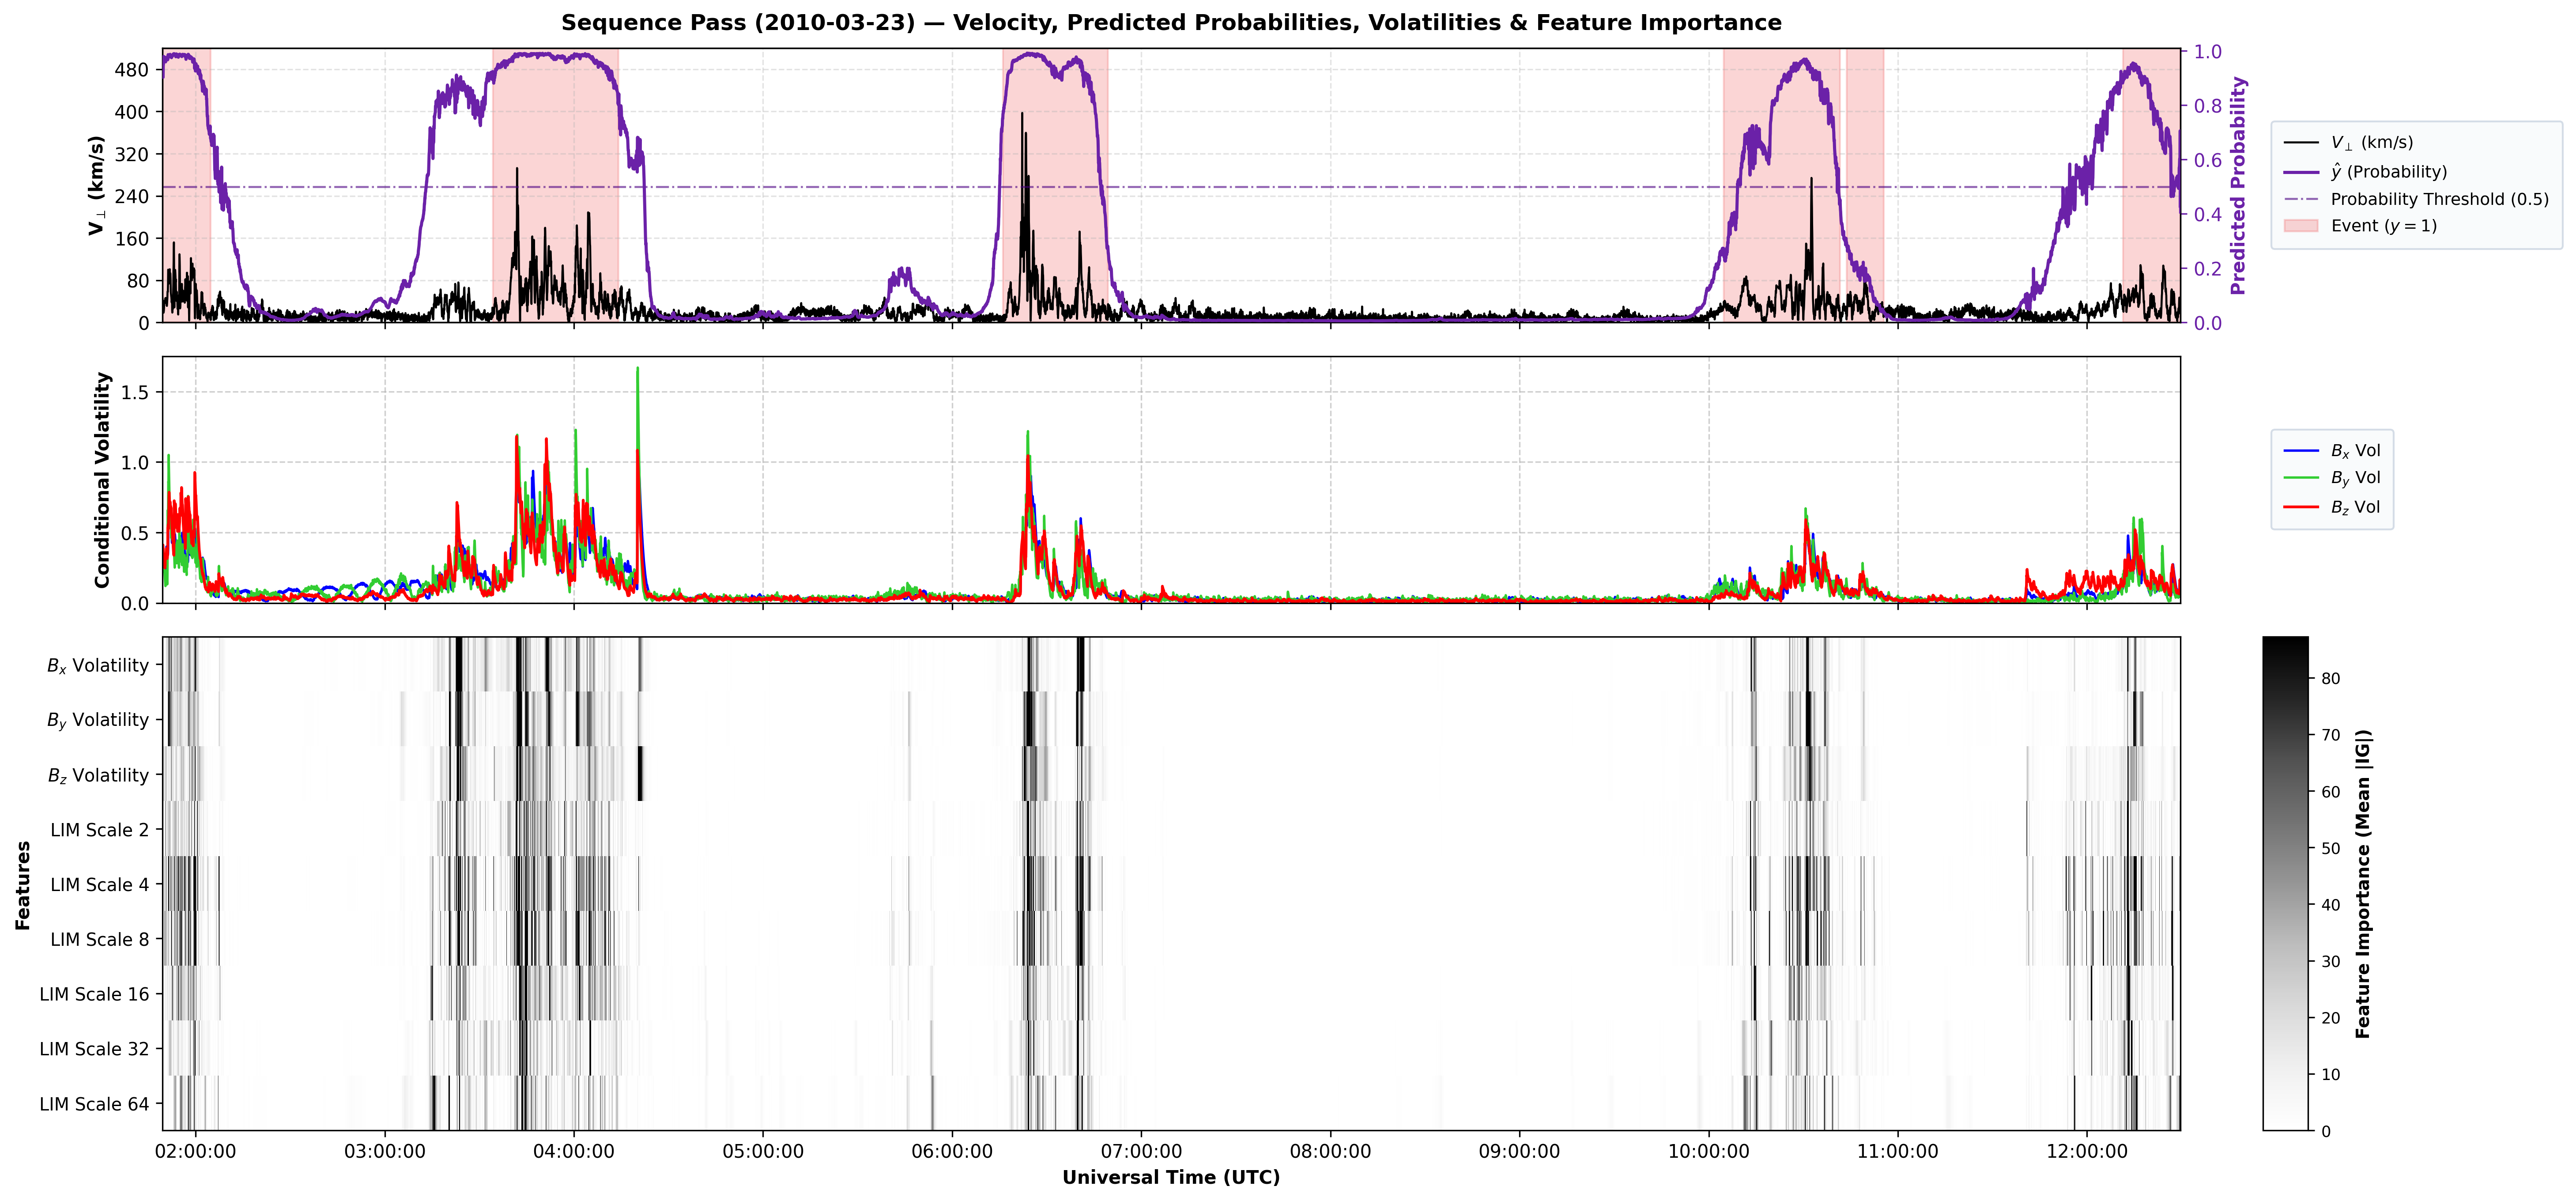

In [30]:
# Load physical volatilities if not already present
vol_cols = [
    "Bx_conditional_vol_val",
    "By_conditional_vol_val",
    "Bz_conditional_vol_val",
]

# 1. Detect passes directly using Time from df_importance
time_deltas = df_importance["Time"].diff().dt.total_seconds().fillna(0)
seq_ids = (time_deltas > 300).cumsum()

# Pick sequence pass (Pass 242)
chosen_pass_id = 242
pass_mask = seq_ids == chosen_pass_id

seq_df = df_importance[pass_mask].copy()
time_vals = pd.to_datetime(seq_df["Time"])
time_nums = mdates.date2num(time_vals)

# Extract pre-standardized attributions (already scaled globally by 1.4826 * MAD)
seq_saliency = seq_df[feat_cols].values.T  # Shape: (len(feat_cols), T_full)
pass_date_str = time_vals.iloc[0].strftime("%Y-%m-%d")

# Clean labels for Panel 3 heatmap y-ticks
clean_feat_labels = [
    label.replace("Bx_conditional_vol", r"$B_x$ Volatility")
    .replace("By_conditional_vol", r"$B_y$ Volatility")
    .replace("Bz_conditional_vol", r"$B_z$ Volatility")
    .replace("LIM_scale_", "LIM Scale ")
    .replace("_log", "")
    for label in feat_labels
]

# 2. Layout: 3 Rows x 2 Columns (Left: Plots, Right: Aligned Controls/Legends/Cbar)
fig = plt.figure(figsize=(18, 9.5), dpi=300)
gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[1.0, 0.9, 1.8],
    width_ratios=[45, 1],  # Narrowed right column to slim the colorbar
    wspace=0.08,
    hspace=0.10,
)

ax1 = fig.add_subplot(gs[0, 0])
ax_leg1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax_leg2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
cax = fig.add_subplot(gs[2, 1])

ax_leg1.axis("off")
ax_leg2.axis("off")

# ==================== PANEL 1: PHYSICAL CONTEXT & PREDICTIONS ====================
v_perp = (
    df.loc[seq_df.index, "|V_perp|"]
    if "|V_perp|" in df.columns
    else seq_df["|V_perp|"]
)

(line_v,) = ax1.plot(
    time_vals,
    v_perp,
    color="black",
    linewidth=1.1,
    zorder=2,
    label=r"$V_\perp\ (\mathrm{km/s})$",
)
ax1.set_ylabel(r"V$_\perp$ (km/s)", fontsize=10, fontweight="bold")
ax1.set_yticks([0, 80, 160, 240, 320, 400, 480])
ax1.set_ylim(0, 520)
ax1.grid(True, linestyle="--", alpha=0.35)

# Event window shading
event_mask = seq_df["Event_label_80"].values
poly_event = ax1.fill_between(
    time_vals,
    0,
    1,
    where=(event_mask == 1),
    color="#ef4444",
    alpha=0.22,
    zorder=0,
    transform=ax1.get_xaxis_transform(),
    label=r"Event ($y=1$)",
)

# Right y-axis: Predicted Probabilities (Deep Violet)
prob_color = "#6b21a8"  # Elegant, high-contrast deep purple
ax1_twin = ax1.twinx()
pred_probs = (
    df.loc[seq_df.index, "Event_pred_probas"]
    if "Event_pred_probas" in df.columns
    else seq_df["Event_pred_probas"]
)

(line_prob,) = ax1_twin.plot(
    time_vals,
    pred_probs,
    color=prob_color,
    linewidth=1.7,
    zorder=3,
    label=r"$\hat{y}$ (Probability)",
)
ax1_twin.set_ylabel(
    "Predicted Probability", fontsize=10, fontweight="bold", color=prob_color
)

# Probability Threshold Line
line_thresh = ax1_twin.axhline(
    0.5,
    color="indigo",
    linestyle="-.",
    linewidth=1.1,
    alpha=0.6,
    zorder=2,
    label="Probability Threshold (0.5)",
)
ax1_twin.set_ylim(0, 1.01)
ax1_twin.tick_params(axis="y", colors=prob_color)

# Legend Panel 1
handles1 = [line_v, line_prob, line_thresh, poly_event]
labels1 = [h.get_label() for h in handles1]
ax_leg1.legend(
    handles=handles1,
    labels=labels1,
    loc="center left",
    frameon=True,
    facecolor="#f8fafc",
    edgecolor="#cbd5e1",
    fontsize=9.0,
    borderpad=0.8,
    labelspacing=0.6,
)

ax1.set_title(
    f"Sequence Pass ({pass_date_str}) — Velocity, Predicted Probabilities, Volatilities & Feature Importance",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
plt.setp(ax1.get_xticklabels(), visible=False)

# ==================== PANEL 2: GARCH CONDITIONAL VOLATILITIES ====================
(l_bx,) = ax2.plot(
    time_vals,
    seq_df["Bx_conditional_vol_val"],
    color="blue",
    linewidth=1.3,
    label=r"$B_x$ Vol",
)
(l_by,) = ax2.plot(
    time_vals,
    seq_df["By_conditional_vol_val"],
    color="limegreen",
    linewidth=1.3,
    label=r"$B_y$ Vol",
)
(l_bz,) = ax2.plot(
    time_vals,
    seq_df["Bz_conditional_vol_val"],
    color="red",
    linewidth=1.5,
    label=r"$B_z$ Vol",
)

ax2.set_ylabel("Conditional Volatility", fontsize=10, fontweight="bold")
ax2.set_ylim(0, 1.75)
ax2.grid(True, linestyle="--", alpha=0.6)

# Legend Panel 2
handles2 = [l_bx, l_by, l_bz]
labels2 = [h.get_label() for h in handles2]
ax_leg2.legend(
    handles=handles2,
    labels=labels2,
    loc="center left",
    frameon=True,
    facecolor="#f8fafc",
    edgecolor="#cbd5e1",
    fontsize=9.0,
    borderpad=0.8,
    labelspacing=0.6,
)
plt.setp(ax2.get_xticklabels(), visible=False)

# ==================== PANEL 3: INVERTED ATTRIBUTION HEATMAP ====================
vmax_val = np.percentile(seq_saliency, 98.5)

im = ax3.imshow(
    seq_saliency,
    aspect="auto",
    cmap="Greys",
    interpolation="nearest",
    origin="upper",
    extent=[time_nums[0], time_nums[-1], len(feat_cols) - 0.5, -0.5],
    vmin=0,
    vmax=vmax_val,
)

ax3.set_yticks(range(len(feat_cols)))
ax3.set_yticklabels(clean_feat_labels, fontsize=9.5)
ax3.set_ylabel("Features", fontsize=10, fontweight="bold")
ax3.set_xlabel("Universal Time (UTC)", fontsize=10, fontweight="bold")

ax3.set_xlim(time_nums[0], time_nums[-1])
ax3.xaxis_date()
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

# Colorbar for Panel 3
cbar = fig.colorbar(im, cax=cax, orientation="vertical")
cbar.set_label(
    r"Feature Importance (Mean |IG|)", fontsize=9.5, fontweight="bold", labelpad=8
)
cbar.ax.tick_params(labelsize=8.5)

plt.subplots_adjust(
    left=0.07, right=0.97, top=0.94, bottom=0.08, hspace=0.10, wspace=0.06
)
plt.show()

In [13]:
# 1097
# 9589575
# 9589929

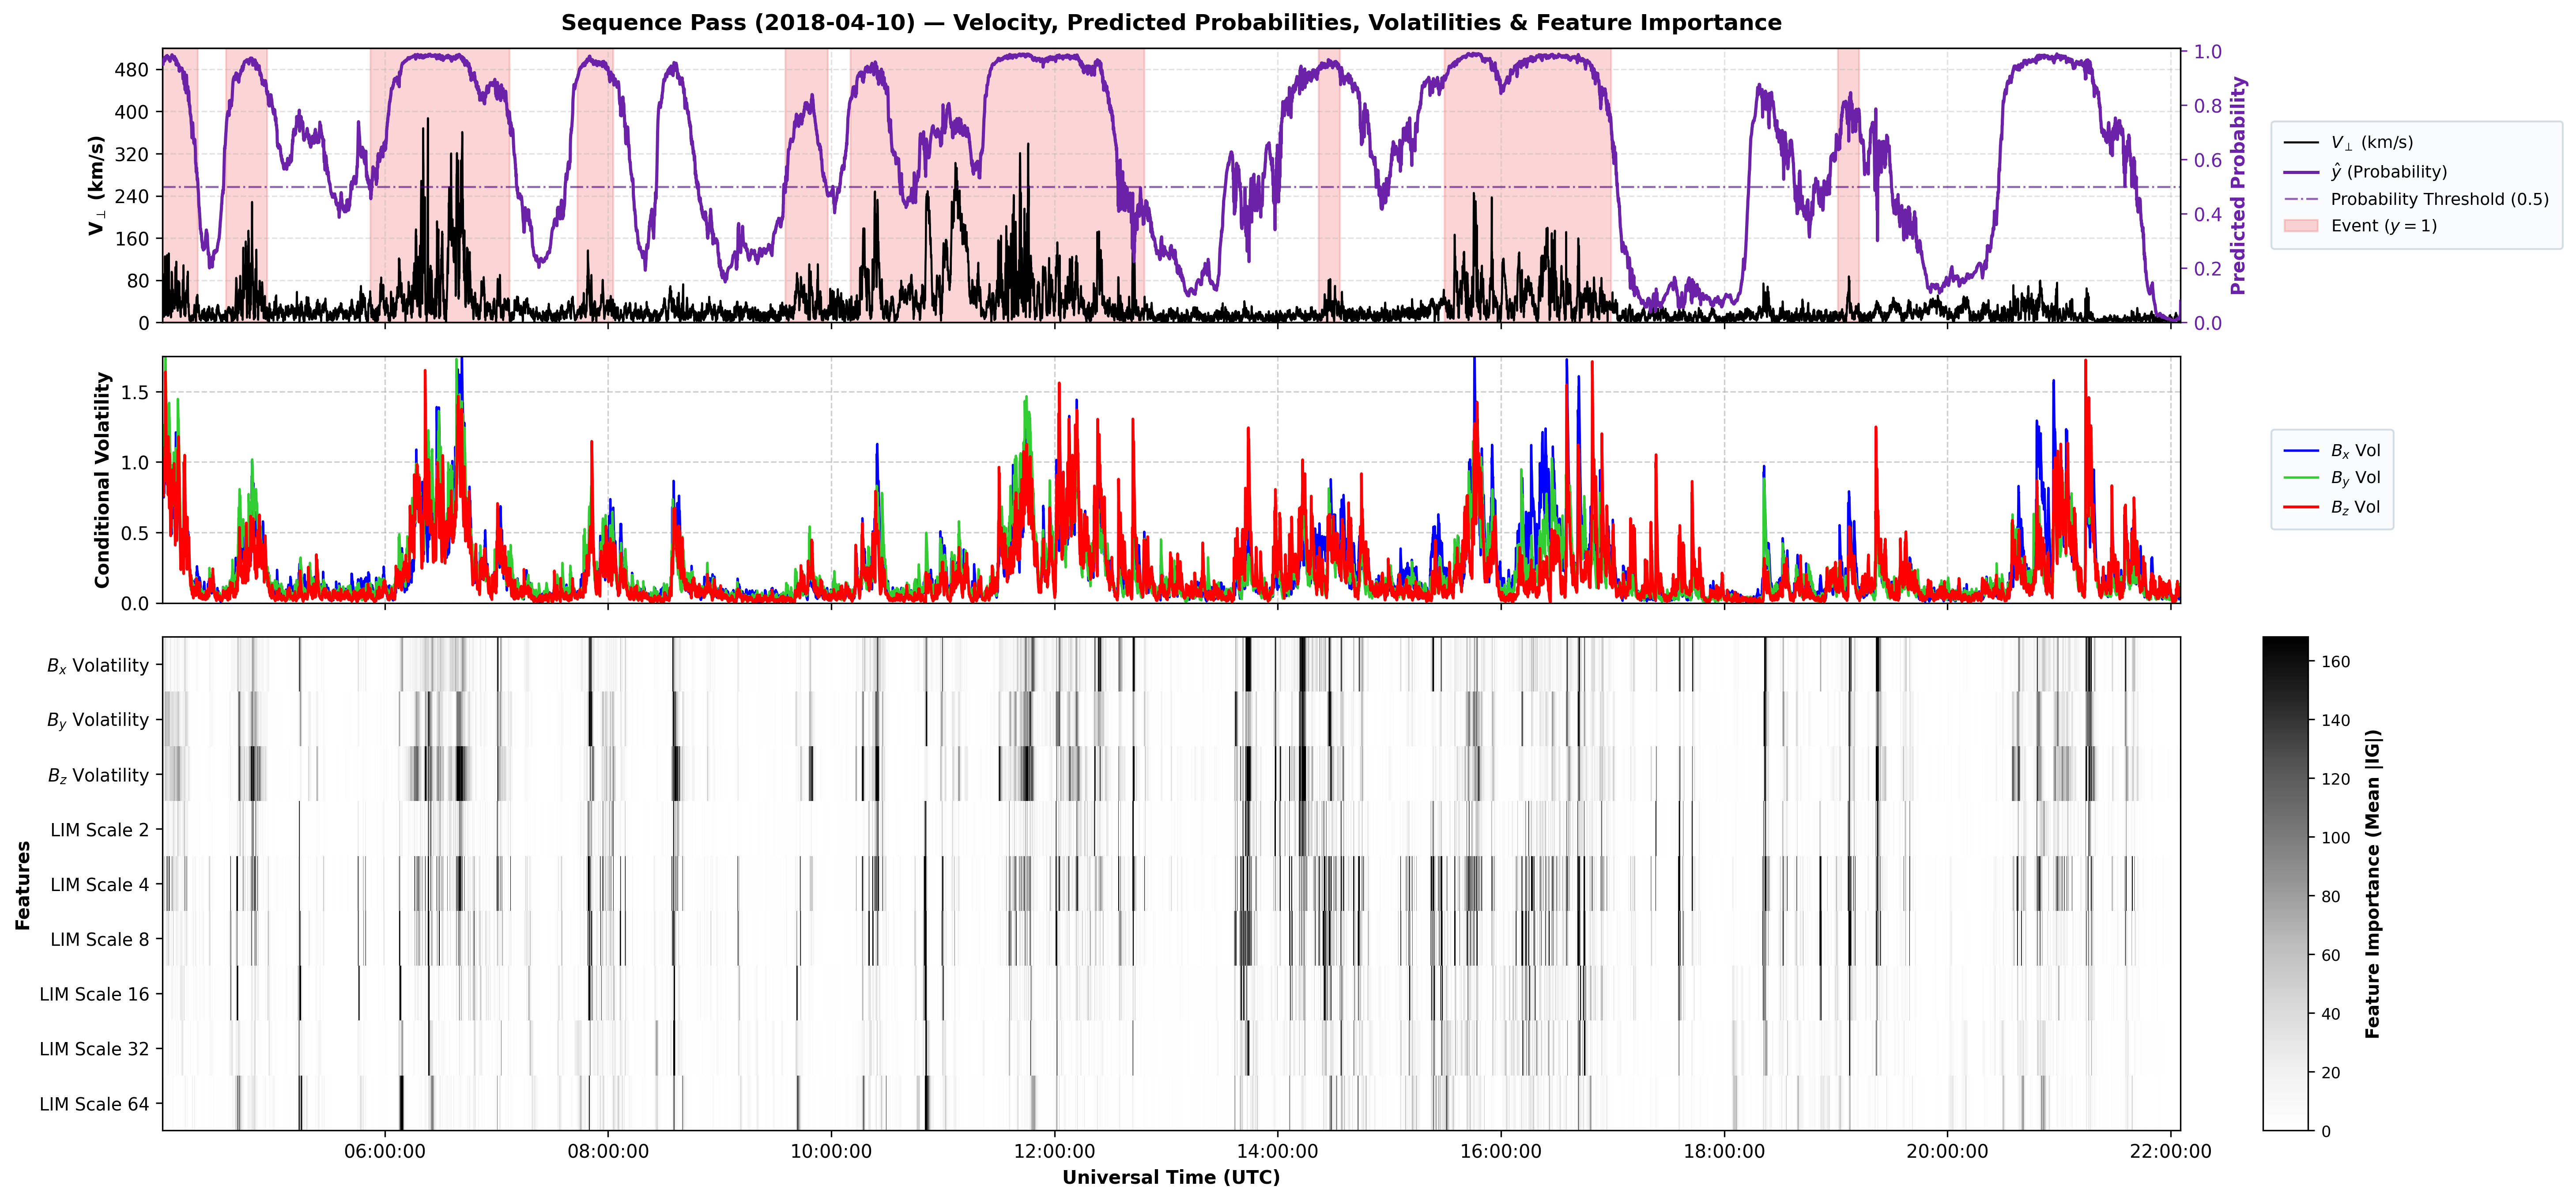

In [27]:
# Load physical volatilities if not already present
vol_cols = [
    "Bx_conditional_vol_val",
    "By_conditional_vol_val",
    "Bz_conditional_vol_val",
]

# 1. Detect passes directly using Time from df_importance
time_deltas = df_importance["Time"].diff().dt.total_seconds().fillna(0)
seq_ids = (time_deltas > 300).cumsum()

# Pick sequence pass (Pass 242)
chosen_pass_id = 1097
pass_mask = seq_ids == chosen_pass_id

seq_df = df_importance[pass_mask].copy()
time_vals = pd.to_datetime(seq_df["Time"])
time_nums = mdates.date2num(time_vals)

# Extract pre-standardized attributions (already scaled globally by 1.4826 * MAD)
seq_saliency = seq_df[feat_cols].values.T  # Shape: (len(feat_cols), T_full)
pass_date_str = time_vals.iloc[0].strftime("%Y-%m-%d")

# Clean labels for Panel 3 heatmap y-ticks
clean_feat_labels = [
    label.replace("Bx_conditional_vol", r"$B_x$ Volatility")
    .replace("By_conditional_vol", r"$B_y$ Volatility")
    .replace("Bz_conditional_vol", r"$B_z$ Volatility")
    .replace("LIM_scale_", "LIM Scale ")
    .replace("_log", "")
    for label in feat_labels
]

# 2. Layout: 3 Rows x 2 Columns (Left: Plots, Right: Aligned Controls/Legends/Cbar)
fig = plt.figure(figsize=(18, 9.5), dpi=300)
gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[1.0, 0.9, 1.8],
    width_ratios=[45, 1],  # Narrowed right column to slim the colorbar
    wspace=0.08,
    hspace=0.10,
)

ax1 = fig.add_subplot(gs[0, 0])
ax_leg1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax_leg2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
cax = fig.add_subplot(gs[2, 1])

ax_leg1.axis("off")
ax_leg2.axis("off")

# ==================== PANEL 1: PHYSICAL CONTEXT & PREDICTIONS ====================
v_perp = (
    df.loc[seq_df.index, "|V_perp|"]
    if "|V_perp|" in df.columns
    else seq_df["|V_perp|"]
)

(line_v,) = ax1.plot(
    time_vals,
    v_perp,
    color="black",
    linewidth=1.1,
    zorder=2,
    label=r"$V_\perp\ (\mathrm{km/s})$",
)
ax1.set_ylabel(r"V$_\perp$ (km/s)", fontsize=10, fontweight="bold")
ax1.set_yticks([0, 80, 160, 240, 320, 400, 480])
ax1.set_ylim(0, 520)
ax1.grid(True, linestyle="--", alpha=0.35)

# Event window shading
event_mask = seq_df["Event_label_80"].values
poly_event = ax1.fill_between(
    time_vals,
    0,
    1,
    where=(event_mask == 1),
    color="#ef4444",
    alpha=0.22,
    zorder=0,
    transform=ax1.get_xaxis_transform(),
    label=r"Event ($y=1$)",
)

# Right y-axis: Predicted Probabilities (Deep Violet)
prob_color = "#6b21a8"  # Elegant, high-contrast deep purple
ax1_twin = ax1.twinx()
pred_probs = (
    df.loc[seq_df.index, "Event_pred_probas"]
    if "Event_pred_probas" in df.columns
    else seq_df["Event_pred_probas"]
)

(line_prob,) = ax1_twin.plot(
    time_vals,
    pred_probs,
    color=prob_color,
    linewidth=1.7,
    zorder=3,
    label=r"$\hat{y}$ (Probability)",
)
ax1_twin.set_ylabel(
    "Predicted Probability", fontsize=10, fontweight="bold", color=prob_color
)

# Probability Threshold Line
line_thresh = ax1_twin.axhline(
    0.5,
    color="indigo",
    linestyle="-.",
    linewidth=1.1,
    alpha=0.6,
    zorder=2,
    label="Probability Threshold (0.5)",
)
ax1_twin.set_ylim(0, 1.01)
ax1_twin.tick_params(axis="y", colors=prob_color)

# Legend Panel 1
handles1 = [line_v, line_prob, line_thresh, poly_event]
labels1 = [h.get_label() for h in handles1]
ax_leg1.legend(
    handles=handles1,
    labels=labels1,
    loc="center left",
    frameon=True,
    facecolor="#f8fafc",
    edgecolor="#cbd5e1",
    fontsize=9.0,
    borderpad=0.8,
    labelspacing=0.6,
)

ax1.set_title(
    f"Sequence Pass ({pass_date_str}) — Velocity, Predicted Probabilities, Volatilities & Feature Importance",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
plt.setp(ax1.get_xticklabels(), visible=False)

# ==================== PANEL 2: GARCH CONDITIONAL VOLATILITIES ====================
(l_bx,) = ax2.plot(
    time_vals,
    seq_df["Bx_conditional_vol_val"],
    color="blue",
    linewidth=1.3,
    label=r"$B_x$ Vol",
)
(l_by,) = ax2.plot(
    time_vals,
    seq_df["By_conditional_vol_val"],
    color="limegreen",
    linewidth=1.3,
    label=r"$B_y$ Vol",
)
(l_bz,) = ax2.plot(
    time_vals,
    seq_df["Bz_conditional_vol_val"],
    color="red",
    linewidth=1.5,
    label=r"$B_z$ Vol",
)

ax2.set_ylabel("Conditional Volatility", fontsize=10, fontweight="bold")
ax2.set_ylim(0, 1.75)
ax2.grid(True, linestyle="--", alpha=0.6)

# Legend Panel 2
handles2 = [l_bx, l_by, l_bz]
labels2 = [h.get_label() for h in handles2]
ax_leg2.legend(
    handles=handles2,
    labels=labels2,
    loc="center left",
    frameon=True,
    facecolor="#f8fafc",
    edgecolor="#cbd5e1",
    fontsize=9.0,
    borderpad=0.8,
    labelspacing=0.6,
)
plt.setp(ax2.get_xticklabels(), visible=False)

# ==================== PANEL 3: INVERTED ATTRIBUTION HEATMAP ====================
vmax_val = np.percentile(seq_saliency, 98.5)

im = ax3.imshow(
    seq_saliency,
    aspect="auto",
    cmap="Greys",
    interpolation="nearest",
    origin="upper",
    extent=[time_nums[0], time_nums[-1], len(feat_cols) - 0.5, -0.5],
    vmin=0,
    vmax=vmax_val,
)

ax3.set_yticks(range(len(feat_cols)))
ax3.set_yticklabels(clean_feat_labels, fontsize=9.5)
ax3.set_ylabel("Features", fontsize=10, fontweight="bold")
ax3.set_xlabel("Universal Time (UTC)", fontsize=10, fontweight="bold")

ax3.set_xlim(time_nums[0], time_nums[-1])
ax3.xaxis_date()
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

# Colorbar for Panel 3
cbar = fig.colorbar(im, cax=cax, orientation="vertical")
cbar.set_label(
    r"Feature Importance (Mean |IG|)", fontsize=9.5, fontweight="bold", labelpad=8
)
cbar.ax.tick_params(labelsize=8.5)

plt.subplots_adjust(
    left=0.07, right=0.97, top=0.94, bottom=0.08, hspace=0.10, wspace=0.06
)
plt.show()

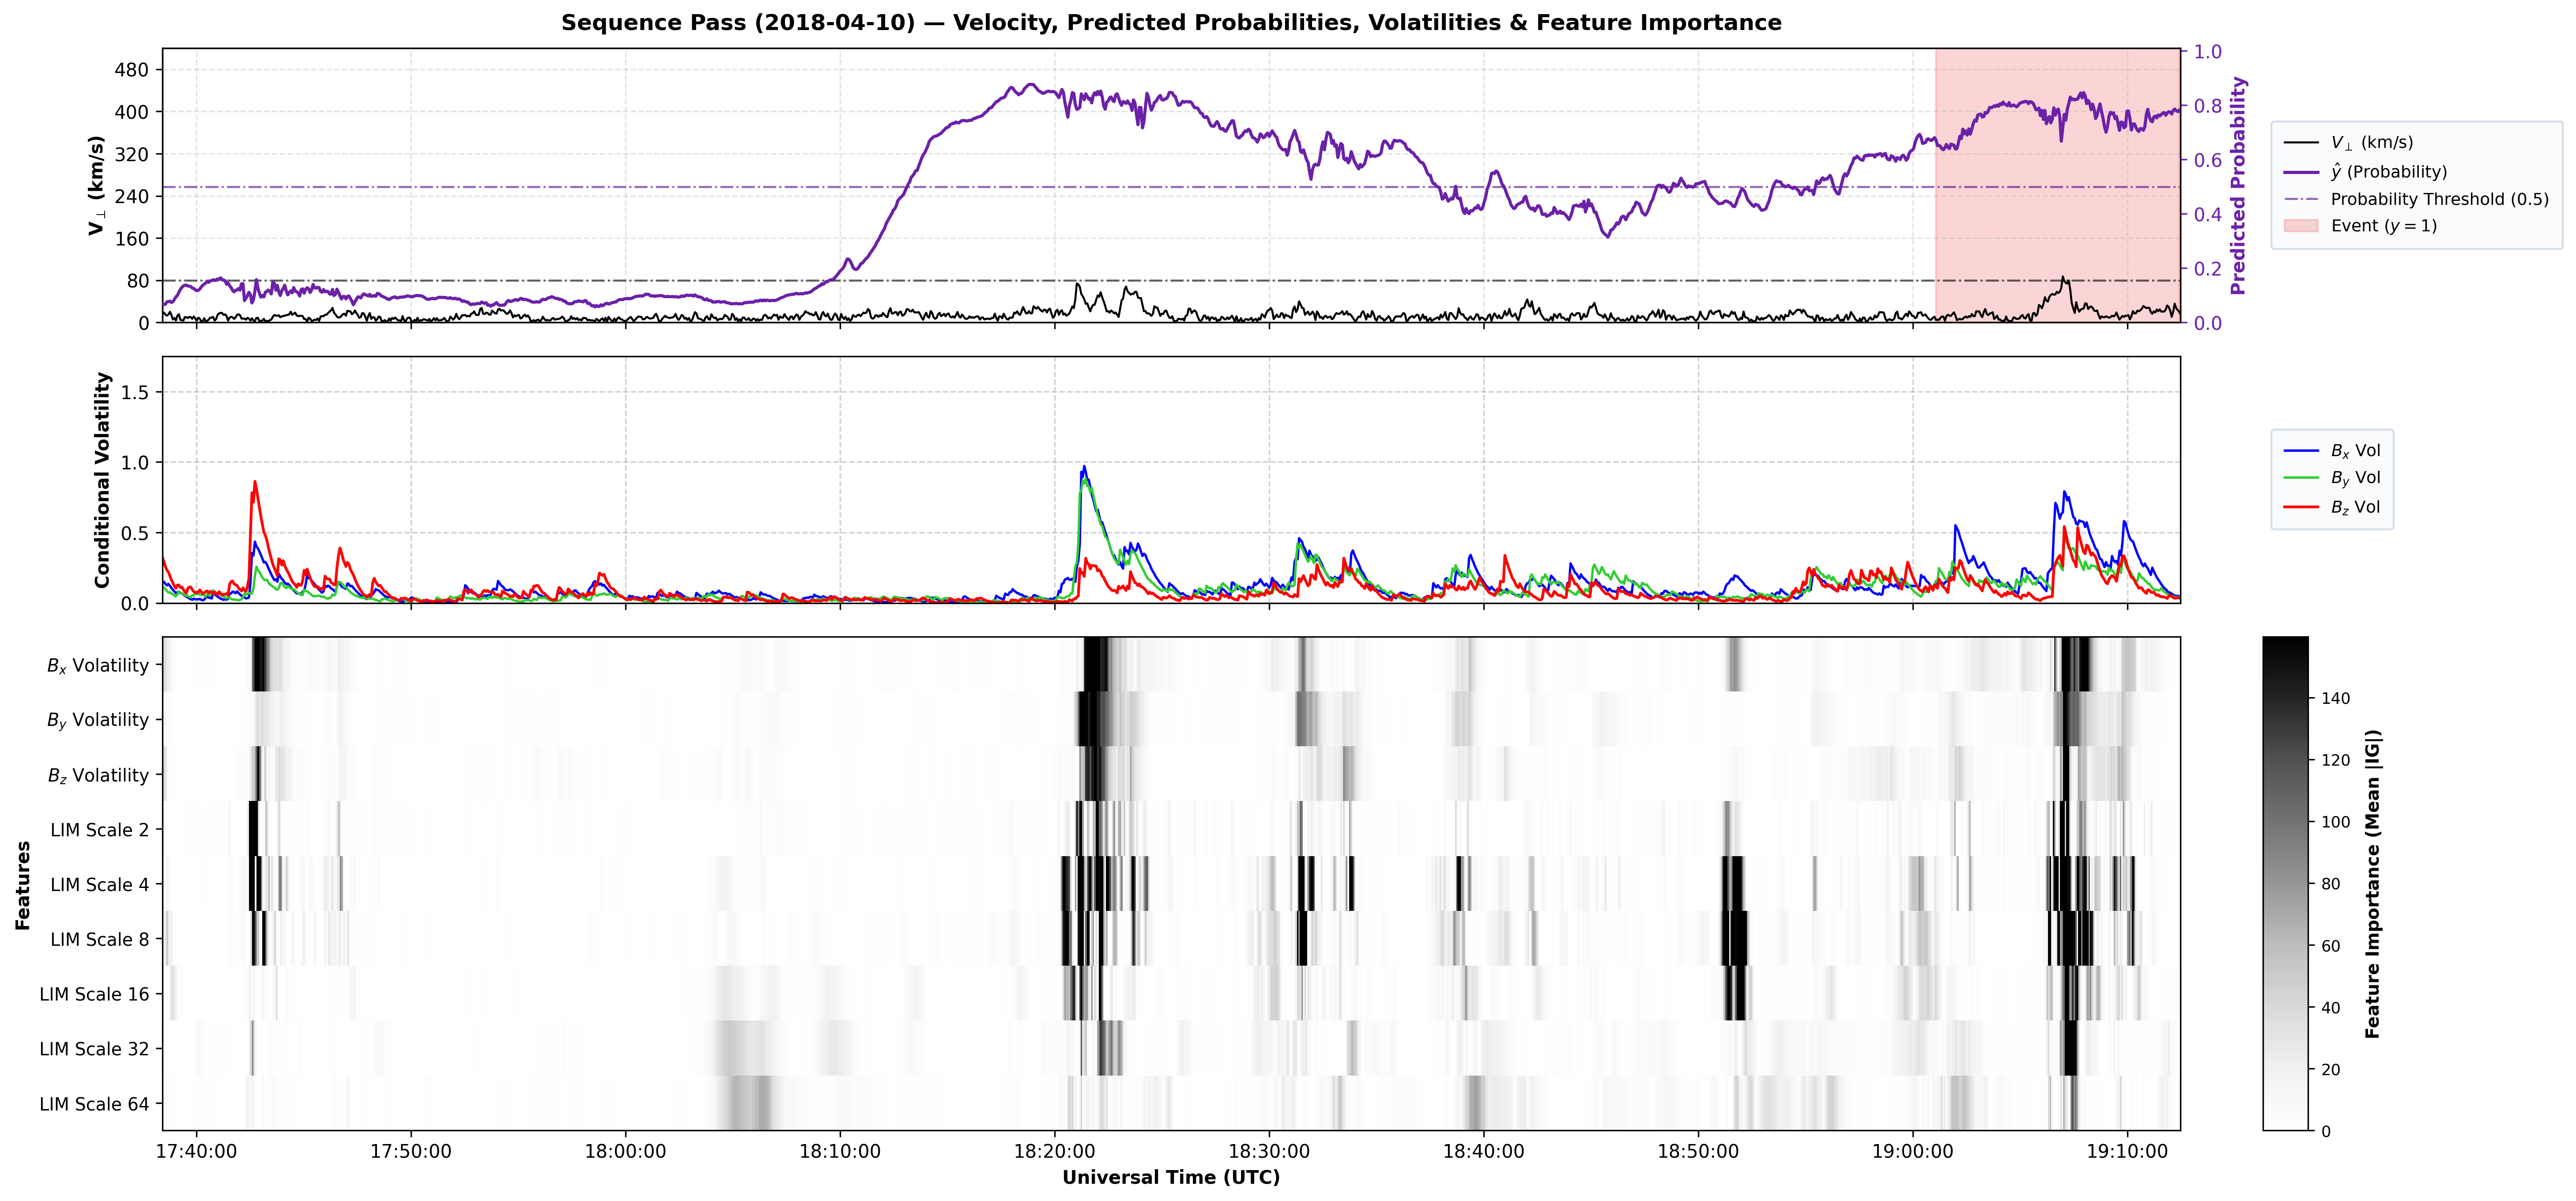

In [28]:
# Load physical volatilities if not already present
vol_cols = [
    "Bx_conditional_vol_val",
    "By_conditional_vol_val",
    "Bz_conditional_vol_val",
]

# 1. Detect passes directly using Time from df_importance
time_deltas = df_importance["Time"].diff().dt.total_seconds().fillna(0)
seq_ids = (time_deltas > 300).cumsum()

# # Pick sequence pass (Pass 242)
# chosen_pass_id = 1097
# pass_mask = seq_ids == chosen_pass_id

start_idx = 9589575 - 500
end_idx = 9589929 + 500

seq_df = df_importance.iloc[start_idx:end_idx].copy()

# seq_df = df_importance[pass_mask].copy()
time_vals = pd.to_datetime(seq_df["Time"])
time_nums = mdates.date2num(time_vals)

# Extract pre-standardized attributions (already scaled globally by 1.4826 * MAD)
seq_saliency = seq_df[feat_cols].values.T  # Shape: (len(feat_cols), T_full)
pass_date_str = time_vals.iloc[0].strftime("%Y-%m-%d")

# Clean labels for Panel 3 heatmap y-ticks
clean_feat_labels = [
    label.replace("Bx_conditional_vol", r"$B_x$ Volatility")
    .replace("By_conditional_vol", r"$B_y$ Volatility")
    .replace("Bz_conditional_vol", r"$B_z$ Volatility")
    .replace("LIM_scale_", "LIM Scale ")
    .replace("_log", "")
    for label in feat_labels
]

# 2. Layout: 3 Rows x 2 Columns (Left: Plots, Right: Aligned Controls/Legends/Cbar)
fig = plt.figure(figsize=(18, 9.5), dpi=300)
gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[1.0, 0.9, 1.8],
    width_ratios=[45, 1],  # Narrowed right column to slim the colorbar
    wspace=0.08,
    hspace=0.10,
)

ax1 = fig.add_subplot(gs[0, 0])
ax_leg1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax_leg2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
cax = fig.add_subplot(gs[2, 1])

ax_leg1.axis("off")
ax_leg2.axis("off")

# ==================== PANEL 1: PHYSICAL CONTEXT & PREDICTIONS ====================
v_perp = (
    df.loc[seq_df.index, "|V_perp|"]
    if "|V_perp|" in df.columns
    else seq_df["|V_perp|"]
)

(line_v,) = ax1.plot(
    time_vals,
    v_perp,
    color="black",
    linewidth=1.1,
    zorder=2,
    label=r"$V_\perp\ (\mathrm{km/s})$",
)

line_vel = ax1.axhline(
    80,
    color="black",
    linestyle="-.",
    linewidth=1.1,
    alpha=0.6,
    zorder=2,
    label="Velocity Threshold (80 km/s)",
)

ax1.set_ylabel(r"V$_\perp$ (km/s)", fontsize=10, fontweight="bold")
ax1.set_yticks([0, 80, 160, 240, 320, 400, 480])
ax1.set_ylim(0, 520)
ax1.grid(True, linestyle="--", alpha=0.35)

# Event window shading
event_mask = seq_df["Event_label_80"].values
poly_event = ax1.fill_between(
    time_vals,
    0,
    1,
    where=(event_mask == 1),
    color="#ef4444",
    alpha=0.22,
    zorder=0,
    transform=ax1.get_xaxis_transform(),
    label=r"Event ($y=1$)",
)

# Right y-axis: Predicted Probabilities (Deep Violet)
prob_color = "#6b21a8"  # Elegant, high-contrast deep purple
ax1_twin = ax1.twinx()
pred_probs = (
    df.loc[seq_df.index, "Event_pred_probas"]
    if "Event_pred_probas" in df.columns
    else seq_df["Event_pred_probas"]
)

(line_prob,) = ax1_twin.plot(
    time_vals,
    pred_probs,
    color=prob_color,
    linewidth=1.7,
    zorder=3,
    label=r"$\hat{y}$ (Probability)",
)
ax1_twin.set_ylabel(
    "Predicted Probability", fontsize=10, fontweight="bold", color=prob_color
)

# Probability Threshold Line
line_thresh = ax1_twin.axhline(
    0.5,
    color="indigo",
    linestyle="-.",
    linewidth=1.1,
    alpha=0.6,
    zorder=2,
    label="Probability Threshold (0.5)",
)
ax1_twin.set_ylim(0, 1.01)
ax1_twin.tick_params(axis="y", colors=prob_color)

# Legend Panel 1
handles1 = [line_v, line_prob, line_thresh, poly_event]
labels1 = [h.get_label() for h in handles1]
ax_leg1.legend(
    handles=handles1,
    labels=labels1,
    loc="center left",
    frameon=True,
    facecolor="#f8fafc",
    edgecolor="#cbd5e1",
    fontsize=9.0,
    borderpad=0.8,
    labelspacing=0.6,
)

ax1.set_title(
    f"Sequence Pass ({pass_date_str}) — Velocity, Predicted Probabilities, Volatilities & Feature Importance",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
plt.setp(ax1.get_xticklabels(), visible=False)

# ==================== PANEL 2: GARCH CONDITIONAL VOLATILITIES ====================
(l_bx,) = ax2.plot(
    time_vals,
    seq_df["Bx_conditional_vol_val"],
    color="blue",
    linewidth=1.3,
    label=r"$B_x$ Vol",
)
(l_by,) = ax2.plot(
    time_vals,
    seq_df["By_conditional_vol_val"],
    color="limegreen",
    linewidth=1.3,
    label=r"$B_y$ Vol",
)
(l_bz,) = ax2.plot(
    time_vals,
    seq_df["Bz_conditional_vol_val"],
    color="red",
    linewidth=1.5,
    label=r"$B_z$ Vol",
)

ax2.set_ylabel("Conditional Volatility", fontsize=10, fontweight="bold")
ax2.set_ylim(0, 1.75)
ax2.grid(True, linestyle="--", alpha=0.6)

# Legend Panel 2
handles2 = [l_bx, l_by, l_bz]
labels2 = [h.get_label() for h in handles2]
ax_leg2.legend(
    handles=handles2,
    labels=labels2,
    loc="center left",
    frameon=True,
    facecolor="#f8fafc",
    edgecolor="#cbd5e1",
    fontsize=9.0,
    borderpad=0.8,
    labelspacing=0.6,
)
plt.setp(ax2.get_xticklabels(), visible=False)

# ==================== PANEL 3: INVERTED ATTRIBUTION HEATMAP ====================
vmax_val = np.percentile(seq_saliency, 98.5)

im = ax3.imshow(
    seq_saliency,
    aspect="auto",
    cmap="Greys",
    interpolation="nearest",
    origin="upper",
    extent=[time_nums[0], time_nums[-1], len(feat_cols) - 0.5, -0.5],
    vmin=0,
    vmax=vmax_val,
)

ax3.set_yticks(range(len(feat_cols)))
ax3.set_yticklabels(clean_feat_labels, fontsize=9.5)
ax3.set_ylabel("Features", fontsize=10, fontweight="bold")
ax3.set_xlabel("Universal Time (UTC)", fontsize=10, fontweight="bold")

ax3.set_xlim(time_nums[0], time_nums[-1])
ax3.xaxis_date()
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

# Colorbar for Panel 3
cbar = fig.colorbar(im, cax=cax, orientation="vertical")
cbar.set_label(
    r"Feature Importance (Mean |IG|)", fontsize=9.5, fontweight="bold", labelpad=8
)
cbar.ax.tick_params(labelsize=8.5)

plt.subplots_adjust(
    left=0.07, right=0.97, top=0.94, bottom=0.08, hspace=0.10, wspace=0.06
)
plt.show()

In [16]:
df_sf = pd.read_csv("sustained_false.csv")

In [17]:
# Extract column as a contiguous 1D NumPy array (zero-copy or minimal overhead)
vals = df['|V_perp|'].to_numpy()

# Extract boundary arrays
starts = df_sf['start_idx'].to_numpy()
ends = df_sf['end_idx'].to_numpy()

# Slices in NumPy create views (not copies), so this takes negligible time for 883 rows
# Note: uses ends + 1 if end_idx is inclusive; use vals[s:e] if end_idx is exclusive
df_sf['max_V_perp'] = [vals[s : e + 1].max() for s, e in zip(starts, ends)]

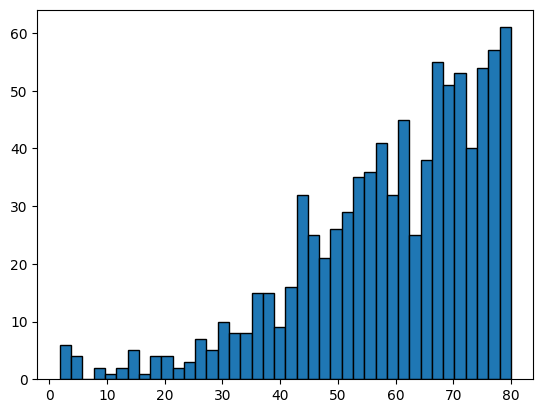

In [18]:
plt.hist(df_sf['max_V_perp'], bins=40, edgecolor='black')
plt.show()

In [19]:
for threshold in [50, 60, 70, 75]:
    print(threshold, (df_sf['max_V_perp'] > threshold).mean())

50 0.7497168742921857
60 0.5503963759909399
70 0.30804077010192527
75 0.16421291053227632
